# Inflation Forecast Data

This notebook downloads, manages, and exports inflation forecast data from the Survey of Professional Forecasters (SPF), produced by the Federal Reserve Bank of Philadelphia, along with actual inflation and interest rate data from FRED. The primary purpose is to construct a ready-to-use dataset illustrating how professional inflation forecasts compare to realized inflation.

This notebook produces two CSV files:

* `inflation_forecast_data_annual.csv`: Annual frequency data
* `inflation_forecast_data_quarterly.csv`: Quarterly frequency data

Each file contains the following columns:

* `date`: Start date of the observation period
* `deflator inflation - forecast`: Median one-year-ahead GDP deflator inflation forecast from the Philadelphia Fed SPF inflation forecast series (`INFPGDP1YR`). One missing value (1974 Q3) has been filled by linear interpolation. For the annual dataset, quarterly forecasts are averaged over the calendar year.
* `deflator inflation - actual`: Realized GDP deflator inflation for the observation period
* `nominal interest`: Average interest rate on one-year U.S. Treasury securities (GS1) for the observation period

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fredpy: a Python wrapper for the FRED API (pip install fredpy) used to create recession bars
import fredpy as fp

# Plot style settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'

# Output directories relative to the notebook location
csv_output_directory ='../csv'
image_output_directory ='../img'

## Download and manage forecast data

The SPF median one-year-ahead GDP deflator inflation forecasts are available from the Philadelphia Fed's consolidated inflation forecast series:

* Data: https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/inflation-forecasts
* Documentation: https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/spf-documentation.pdf

The Excel file `Inflation.xlsx` contains forecasts of several inflation measures. The column used here is:

* `INFPGDP1YR`: Median one-year-ahead GDP deflator inflation forecast

One value is missing (1974 Q3) and is filled by linear interpolation before export.

In [2]:
# Download SPF median GDP deflator level forecasts directly from the Philadelphia Fed
inflation_data = pd.read_excel('https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/historical-data/Inflation.xlsx?sc_lang=en&hash=0E7FC9E86818CF8A1C512953603AA6D8', dtype={'YEAR': str, 'QUARTER': str},sheet_name='INFLATION')

# Construct a quarterly datetime index from the YEAR and QUARTER columns
y = inflation_data.loc[0, 'YEAR']
q = inflation_data.loc[0, 'QUARTER']
m = str(3*(int(q)-1)+1)  # Convert quarter number to starting month (Q1=1, Q2=4, Q3=7, Q4=10)
dates = pd.date_range(start=m+'-1-'+y, periods=len(inflation_data.index), freq='QS')
inflation_data.index = dates

# Interpolate to fill a single missing value for 1974 Q3
inflation_forecast = inflation_data['INFPGDP1YR'].interpolate()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [3]:
# Create a dataset with quarterly frequency.
quarterly_data = pd.DataFrame()

# One-year-ahead GDP deflator inflation forecast (INFPGDP1YR from Philadelphia Fed)
quarterly_data['deflator inflation - forecast'] = inflation_forecast

# Actual GDP deflator inflation: realized four-quarter percentage change (GDPDEF from FRED)
deflator = fp.series('GDPDEF').data
inflation = 100*(deflator.shift(-4)/deflator-1)
quarterly_data['deflator inflation - actual'] = inflation

# One-year Treasury rate (GS1 from FRED), resampled to quarterly frequency
interest1yr = fp.series('GS1').data.resample('QS').mean()
quarterly_data['nominal interest'] = interest1yr

# Drop rows with missing values arising from leads, lags, or data availability
quarterly_data = quarterly_data.dropna()

# Export to CSV
quarterly_data.to_csv(csv_output_directory+'/inflation_forecast_data_quarterly.csv',index=True)

In [4]:
# Create a dataset with annual frequency.
annual_data = pd.DataFrame()

# One-year-ahead GDP deflator inflation forecast (INFPGDP1YR), averaged to annual frequency
annual_data['deflator inflation - forecast'] = inflation_forecast.resample('YS').mean()

# Actual GDP deflator inflation: realized one-year percentage change (GDPDEF from FRED)
deflator = fp.series('GDPDEF').data.resample('YS').mean()
inflation = 100*(deflator.shift(-1)/deflator-1)
annual_data['deflator inflation - actual'] = inflation

# One-year Treasury rate (GS1 from FRED), resampled to annual frequency
interest1yr = fp.series('GS1').data.resample('YS').mean()
annual_data['nominal interest'] = interest1yr

# Drop rows with missing values arising from leads, lags, or data availability
annual_data = annual_data.dropna()

# Export to CSV
annual_data.to_csv(csv_output_directory+'/inflation_forecast_data_annual.csv',index=True)

## Plots

The following cells produce figures showing actual and forecast GDP deflator inflation, with shaded regions indicating periods when inflation was above (green) or below (red) professional forecasts. These figures are intended for use in undergraduate macroeconomics lectures.

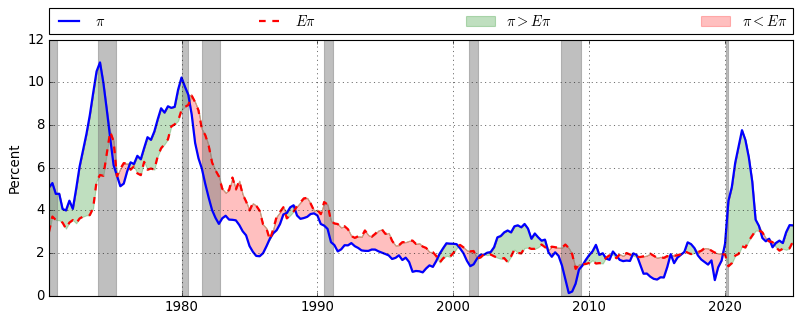

In [5]:
# Quarterly: actual vs. forecast inflation with shading
# Green shading: actual inflation exceeded forecast (π > Eπ)
# Red shading: actual inflation fell short of forecast (π < Eπ)
fig,ax = plt.subplots(figsize=(12,4))
ax.plot(quarterly_data['deflator inflation - actual'],'-b',lw=2,label='$\\pi$')
ax.plot(quarterly_data['deflator inflation - forecast'],'--r',lw=2,label='$E\\pi$')
ax.fill_between(quarterly_data.index,quarterly_data['deflator inflation - forecast'],np.max([quarterly_data['deflator inflation - actual'],quarterly_data['deflator inflation - forecast']],axis=0),color='g',alpha=0.25,label='$\\pi>E\\pi$')
ax.fill_between(quarterly_data.index,np.max([quarterly_data['deflator inflation - actual'],quarterly_data['deflator inflation - forecast']],axis=0),quarterly_data['deflator inflation - actual'],color='r',alpha=0.25,label='$\\pi<E\\pi$')
fp.recessions(start=quarterly_data.index[0],end=quarterly_data.index[-1])
ax.grid()
ax.set_ylabel('Percent')

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,ncol=4,borderaxespad=0., mode="expand",fontsize=13)

plt.savefig(image_output_directory+'/fig_us_inflation_forecast_quarterly.png',bbox_inches='tight');

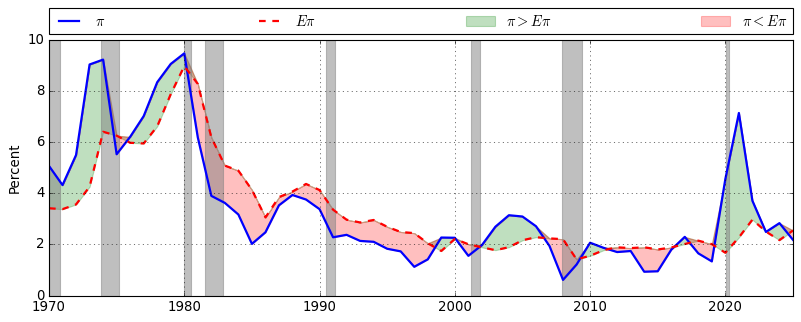

In [6]:
# Annual: actual vs. forecast inflation with shading
# Green shading: actual inflation exceeded forecast (π > Eπ)
# Red shading: actual inflation fell short of forecast (π < Eπ)
# Same figure as above, but with annual data
fig,ax = plt.subplots(figsize=(12,4))
ax.plot(annual_data['deflator inflation - actual'],'-b',lw=2,label='$\\pi$')
ax.plot(annual_data['deflator inflation - forecast'],'--r',lw=2,label='$E\\pi$')
ax.fill_between(annual_data.index,annual_data['deflator inflation - forecast'],np.max([annual_data['deflator inflation - actual'],annual_data['deflator inflation - forecast']],axis=0),color='g',alpha=0.25,label='$\\pi>E\\pi$')
ax.fill_between(annual_data.index,np.max([annual_data['deflator inflation - actual'],annual_data['deflator inflation - forecast']],axis=0),annual_data['deflator inflation - actual'],color='r',alpha=0.25,label='$\\pi<E\\pi$')
fp.recessions(start=annual_data.index[0],end=annual_data.index[-1])
ax.grid()
ax.set_ylabel('Percent')

ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc=3,ncol=4,borderaxespad=0., mode="expand",fontsize=13)

plt.savefig(image_output_directory+'/fig_us_inflation_forecast_annual.png',bbox_inches='tight');

## Ex Ante Real Interest Rate

The ex ante real interest rate is computed as the nominal interest rate minus expected inflation: $r_t=i_t−E_t\pi_{t+1}$. It is not added as a named column or exported to CSV because instructors may wish to have students compute it directly as an exercise in applying the Fisher equation.

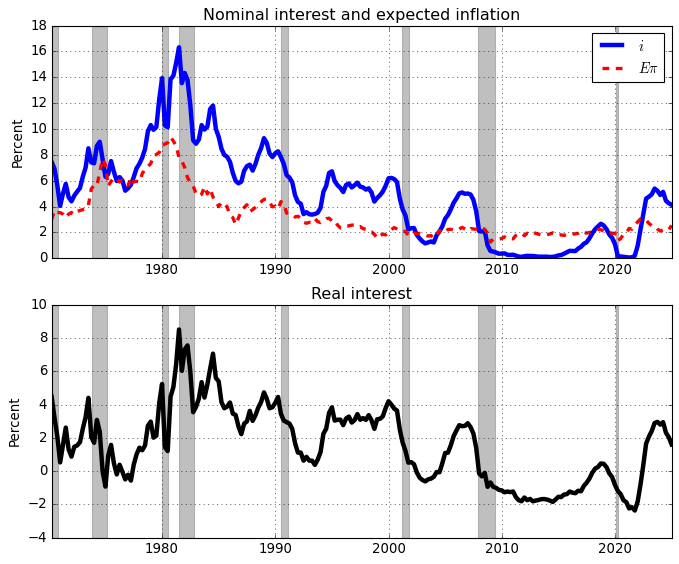

In [7]:
# Quarterly: two-panel figure showing (1) nominal rate and expected inflation,
# and (2) the implied ex ante real interest rate (i - Eπ)
fig = plt.figure(figsize=[10,8])
ax = fig.add_subplot(2,1,1)
ax.plot(quarterly_data['nominal interest'],label='$i$',lw=4)
ax.plot(quarterly_data['deflator inflation - forecast'],'r--',label='$E\\pi$',lw=3)
ax.set_title('Nominal interest and expected inflation')
fp.recessions(start=quarterly_data.index[0],end=quarterly_data.index[-1])
ax.set_ylabel('Percent')
ax.grid()

ax.legend(loc='upper right',ncol=1,fontsize=13)

ax = fig.add_subplot(2,1,2)
ax.plot(quarterly_data['nominal interest']-quarterly_data['deflator inflation - forecast'],'k',lw=4)
fp.recessions(start=quarterly_data.index[0],end=quarterly_data.index[-1])
ax.set_title('Real interest')
ax.set_ylabel('Percent')
ax.grid()

plt.savefig(image_output_directory+'/fig_us_real_interest_rate_quarterly.png',bbox_inches='tight');

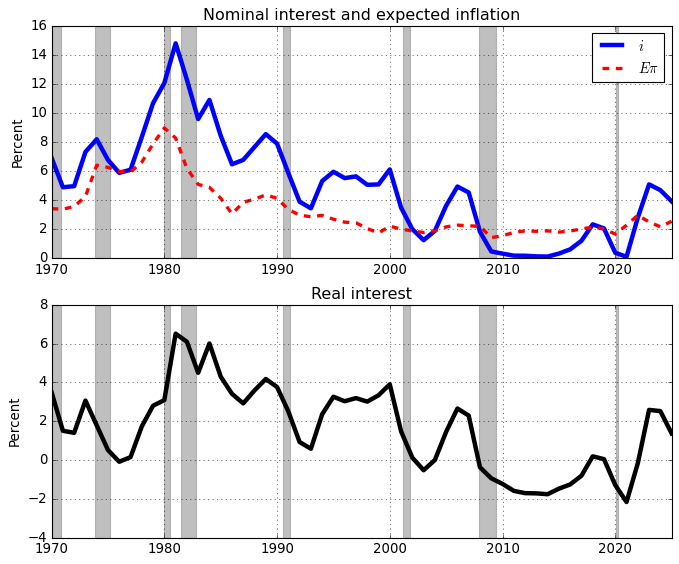

In [8]:
# Annual: two-panel figure showing (1) nominal rate and expected inflation,
# and (2) the implied ex ante real interest rate (i - Eπ)
fig = plt.figure(figsize=[10,8])
ax = fig.add_subplot(2,1,1)
ax.plot(annual_data['nominal interest'],label='$i$',lw=4)
ax.plot(annual_data['deflator inflation - forecast'],'r--',label='$E\\pi$',lw=3)
ax.set_title('Nominal interest and expected inflation')
fp.recessions(start=annual_data.index[0],end=annual_data.index[-1])
ax.set_ylabel('Percent')
ax.grid()

ax.legend(loc='upper right',ncol=1,fontsize=13)

ax = fig.add_subplot(2,1,2)
ax.plot(annual_data['nominal interest']-annual_data['deflator inflation - forecast'],'k',lw=4)
fp.recessions(start=annual_data.index[0],end=annual_data.index[-1])
ax.set_title('Real interest')
ax.set_ylabel('Percent')
ax.grid()

plt.savefig(image_output_directory+'/fig_us_real_interest_rate_annual.png',bbox_inches='tight');